In [1]:
pip install imbalanced-learn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip3.12 install --upgrade pip

  Obtaining dependency information for pip from https://files.pythonhosted.org/packages/3a/eb/fea4d1d51c49832120f7f285d07306db3960f423a2612c6057caf3e8196f/pip-26.1.1-py3-none-any.whl.metadata
Using cached pip-26.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 23.2.1
    Uninstalling pip-23.2.1:
      Successfully uninstalled pip-23.2.1


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

df = pd.read_excel('creditcard.xlsx')

In [3]:
print(df.shape)

(284807, 31)


In [4]:
print(df.duplicated().sum())
df = df.drop_duplicates()
print("After dropping duplicates:", df.shape)

1081
After dropping duplicates: (283726, 31)


In [5]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [6]:
print("\nClass distribution:")
print(df['Class'].value_counts())


Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [7]:
scaler = RobustScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df = df.drop('Amount', axis=1)

print("Amount scaled. New stats:")
print(df['Amount_scaled'].describe())

Amount scaled. New stats:
count    283726.000000
mean          0.924387
std           3.482123
min          -0.305938
25%          -0.228063
50%           0.000000
75%           0.771937
max         356.962314
Name: Amount_scaled, dtype: float64


In [8]:
df['Hour'] = df['Time'].apply(lambda x: (x/3600)%24)
df = df.drop('Time', axis=1)

print("time converted to hour. Distribution:")
print(df['Hour'].describe())

time converted to hour. Distribution:
count    283726.000000
mean         14.537139
std           5.846094
min           0.000000
25%          10.597500
50%          15.008889
75%          19.329167
max          23.999444
Name: Hour, dtype: float64


In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y
                                                   )
print("training set:", X_train.shape)
print("Test_set:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

training set: (226980, 30)
Test_set: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [10]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train )

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())
print("\nResampled training shape:", X_train_res.shape)

Before SMOTE: {0: 226602, 1: 378}
After SMOTE: {0: 226602, 1: 226602}

Resampled training shape: (453204, 30)


In [11]:
print("=" * 50)
print("Pre-processing complete")
print("=" * 50)
print(f"Features: {X_train_res.columns.tolist()}")
print(f"Training samples(resampled): {X_train_res.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Training class balance: {y_train_res.value_counts().to_dict()}")
print(f"Test class balance: {y_test.value_counts().to_dict()}")

Pre-processing complete
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Hour']
Training samples(resampled): 453204
Test samples: 56746
Training class balance: {0: 226602, 1: 226602}
Test class balance: {0: 56651, 1: 95}


In [12]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
print("After Undersampling:", y_train_under.value_counts().to_dict())

After Undersampling: {0: 378, 1: 378}


In [13]:
X_train_res.to_csv('X_train_processed.csv', index=False)
X_test.to_csv('X_test_processed.csv', index=False)
y_train_res.to_csv('y_train_processed.csv', index=False)
y_test.to_csv('y_test_processed.csv', index=False)
print("Saved")

Saved


In [14]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [16]:
!pip3.10 install xgboost==2.1.4

In [18]:
!pip3.10 install --upgrade pip

In [15]:
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

print('All imports successful')

All imports successful


In [16]:
X_train_smote = pd.read_csv('X_train_processed.csv')
X_test        = pd.read_csv('X_test_processed.csv')
y_train_smote = pd.read_csv('y_train_processed.csv').squeeze()
y_test        = pd.read_csv('y_test_processed.csv').squeeze()

print('=== Section 3 Preprocessed Data ===')
print(f'X_train (SMOTE) : {X_train_smote.shape}')
print(f'X_test          : {X_test.shape}')
print(f'y_train balance : {y_train_smote.value_counts().to_dict()}')
print(f'y_test balance  : {y_test.value_counts().to_dict()}')

=== Section 3 Preprocessed Data ===
X_train (SMOTE) : (453204, 30)
X_test          : (56746, 30)
y_train balance : {0: 226602, 1: 226602}
y_test balance  : {0: 56651, 1: 95}


In [18]:
df_raw = pd.read_excel('creditcard.xlsx')
df_raw = df_raw.drop_duplicates()

df_raw['Amount_scaled'] = RobustScaler().fit_transform(df_raw[['Amount']])
df_raw['Hour']          = df_raw['Time'].apply(lambda x: (x / 3600) % 24)
df_raw                  = df_raw.drop(columns=['Amount', 'Time'])

X_raw = df_raw.drop('Class', axis=1)
y_raw = df_raw['Class']

X_train_raw, _, y_train_raw, _ = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)

# Compute scale_pos_weight from raw training distribution
neg, pos       = np.bincount(y_train_raw)
scale_pos_weight = neg / pos

print('=== Raw Training Data (No SMOTE) ===')
print(f'X_train_raw     : {X_train_raw.shape}')
print(f'Class balance   : {y_train_raw.value_counts().to_dict()}')
print(f'scale_pos_weight: {scale_pos_weight:.1f}')

=== Raw Training Data (No SMOTE) ===
X_train_raw     : (226980, 30)
Class balance   : {0: 226602, 1: 378}
scale_pos_weight: 599.5


In [19]:
# Define the three imbalance configurations
configs = {
    'baseline':       (X_train_smote, y_train_smote, 1),
    'cost_sensitive': (X_train_raw,   y_train_raw,   int(scale_pos_weight)),
    'hybrid':         (X_train_smote, y_train_smote, 3),
}

print('Imbalance configurations defined:')
for name, (X_tr, y_tr, spw) in configs.items():
    print(f'  {name:20s} — train shape: {X_tr.shape}, scale_pos_weight: {spw}')

Imbalance configurations defined:
  baseline             — train shape: (453204, 30), scale_pos_weight: 1
  cost_sensitive       — train shape: (226980, 30), scale_pos_weight: 599
  hybrid               — train shape: (453204, 30), scale_pos_weight: 3


In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_param_grid = {
    'classifier__C':       [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver':  ['liblinear']
}

xgb_param_grid = {
    'classifier__max_depth':        [3, 5, 7],
    'classifier__learning_rate':    [0.05, 0.1, 0.3],
    'classifier__n_estimators':     [100, 300],
    'classifier__subsample':        [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

print('CV and parameter grids defined.')

CV and parameter grids defined.


In [21]:
all_results = []

for config_name, (X_tr, y_tr, spw_val) in configs.items():

    print(f'\n{"-"*55}')
    print(f'  CONFIG: {config_name.upper()}')
    print(f'{"-"*55}')

    # --- Logistic Regression ---
    print(f'\n  Training: Logistic Regression | {config_name}')
    lr_pipeline = Pipeline([('classifier', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ))])
    lr_search = RandomizedSearchCV(
        lr_pipeline, lr_param_grid,
        n_iter=20, scoring='average_precision',
        cv=cv, n_jobs=-1, random_state=42, verbose=0
    )
    lr_search.fit(X_tr, y_tr)
    print(f'  Best params    : {lr_search.best_params_}')
    print(f'  Best CV PR-AUC : {lr_search.best_score_:.4f}')
    all_results.append({
        'model': 'Logistic Regression',
        'config': config_name,
        'cv_pr_auc': round(lr_search.best_score_, 4),
        'best_params': lr_search.best_params_,
        'estimator': lr_search.best_estimator_
    })

    # --- XGBoost ---
    print(f'\n  Training: XGBoost | {config_name}')
    xgb_pipeline = Pipeline([('classifier', XGBClassifier(
        scale_pos_weight=spw_val,
        eval_metric='logloss',
        random_state=42, n_jobs=-1
    ))])
    xgb_search = RandomizedSearchCV(
        xgb_pipeline, xgb_param_grid,
        n_iter=20, scoring='average_precision',
        cv=cv, n_jobs=-1, random_state=42, verbose=0
    )
    xgb_search.fit(X_tr, y_tr)
    print(f'  Best params    : {xgb_search.best_params_}')
    print(f'  Best CV PR-AUC : {xgb_search.best_score_:.4f}')
    all_results.append({
        'model': 'XGBoost',
        'config': config_name,
        'cv_pr_auc': round(xgb_search.best_score_, 4),
        'best_params': xgb_search.best_params_,
        'estimator': xgb_search.best_estimator_
    })

print('\nAll experiments complete.')


-------------------------------------------------------
  CONFIG: BASELINE
-------------------------------------------------------

  Training: Logistic Regression | baseline
  Best params    : {'classifier__solver': 'liblinear', 'classifier__penalty': 'l2', 'classifier__C': 10}
  Best CV PR-AUC : 0.9923

  Training: XGBoost | baseline
  Best params    : {'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.3, 'classifier__colsample_bytree': 0.8}
  Best CV PR-AUC : 1.0000

-------------------------------------------------------
  CONFIG: COST_SENSITIVE
-------------------------------------------------------

  Training: Logistic Regression | cost_sensitive
  Best params    : {'classifier__solver': 'liblinear', 'classifier__penalty': 'l2', 'classifier__C': 0.1}
  Best CV PR-AUC : 0.7554

  Training: XGBoost | cost_sensitive
  Best params    : {'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier_

In [22]:
summary_df = pd.DataFrame([{
    'Model':       r['model'],
    'Config':      r['config'],
    'CV PR-AUC':   r['cv_pr_auc'],
    'Best Params': r['best_params']
} for r in all_results])

print('=== TRAINING SUMMARY (CV PR-AUC) ===')
print(summary_df[['Model', 'Config', 'CV PR-AUC']].to_string(index=False))

# Identify best overall
best = max(all_results, key=lambda r: r['cv_pr_auc'])
print(f'\nBest overall: {best["model"]} | {best["config"]} | PR-AUC: {best["cv_pr_auc"]}')

summary_df.to_csv('training_summary.csv', index=False)
print('Saved: training_summary.csv')

=== TRAINING SUMMARY (CV PR-AUC) ===
              Model         Config  CV PR-AUC
Logistic Regression       baseline     0.9923
            XGBoost       baseline     1.0000
Logistic Regression cost_sensitive     0.7554
            XGBoost cost_sensitive     0.8552
Logistic Regression         hybrid     0.9923
            XGBoost         hybrid     1.0000

Best overall: XGBoost | baseline | PR-AUC: 1.0
Saved: training_summary.csv


In [23]:
export = {
    'models': {f"{r['model']}_{r['config']}": r['estimator'] for r in all_results},
    'X_test': X_test,
    'y_test': y_test
}

with open('trained_models.pkl', 'wb') as f:
    pickle.dump(export, f)

print('Exported: trained_models.pkl')
print('Contains:')
for key in export['models'].keys():
    print(f'  - {key}')
print(f'  - X_test : {X_test.shape}')
print(f'  - y_test : {y_test.shape}')
print('\nPass trained_models.pkl to the evaluation section.')

Exported: trained_models.pkl
Contains:
  - Logistic Regression_baseline
  - XGBoost_baseline
  - Logistic Regression_cost_sensitive
  - XGBoost_cost_sensitive
  - Logistic Regression_hybrid
  - XGBoost_hybrid
  - X_test : (56746, 30)
  - y_test : (56746,)

Pass trained_models.pkl to the evaluation section.


In [37]:
pip install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 573.0 kB/s  0:00:14m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 473.7 kB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 298.3 kB/s  0:00:15 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]
Note: you may need to restart the kernel to use updated packages.


In [38]:
import pickle
from sklearn.metrics import (classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

with open('trained_models.pkl', 'rb') as f:
    export = pickle.load(f)
models = export['models']
X_test = export['X_test']
y_test = export['y_test']

In [39]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f'\n=== {name} ===')
    print(classification_report(
        y_test, y_pred, digits=4))
    print(f'AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}')
    print(f'AUC-PR:  {average_precision_score(
        y_test, y_prob):.4f}')



=== Logistic Regression_baseline ===
              precision    recall  f1-score   support

           0     0.9998    0.9739    0.9867     56651
           1     0.0532    0.8737    0.1004        95

    accuracy                         0.9738     56746
   macro avg     0.5265    0.9238    0.5435     56746
weighted avg     0.9982    0.9738    0.9852     56746

AUC-ROC: 0.9615
AUC-PR:  0.6792

=== XGBoost_baseline ===
              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     56651
           1     0.8706    0.7789    0.8222        95

    accuracy                         0.9994     56746
   macro avg     0.9351    0.8894    0.9110     56746
weighted avg     0.9994    0.9994    0.9994     56746

AUC-ROC: 0.9773
AUC-PR:  0.8067

=== Logistic Regression_cost_sensitive ===
              precision    recall  f1-score   support

           0     0.9998    0.9753    0.9874     56651
           1     0.0560    0.8737    0.1053        95

    accura

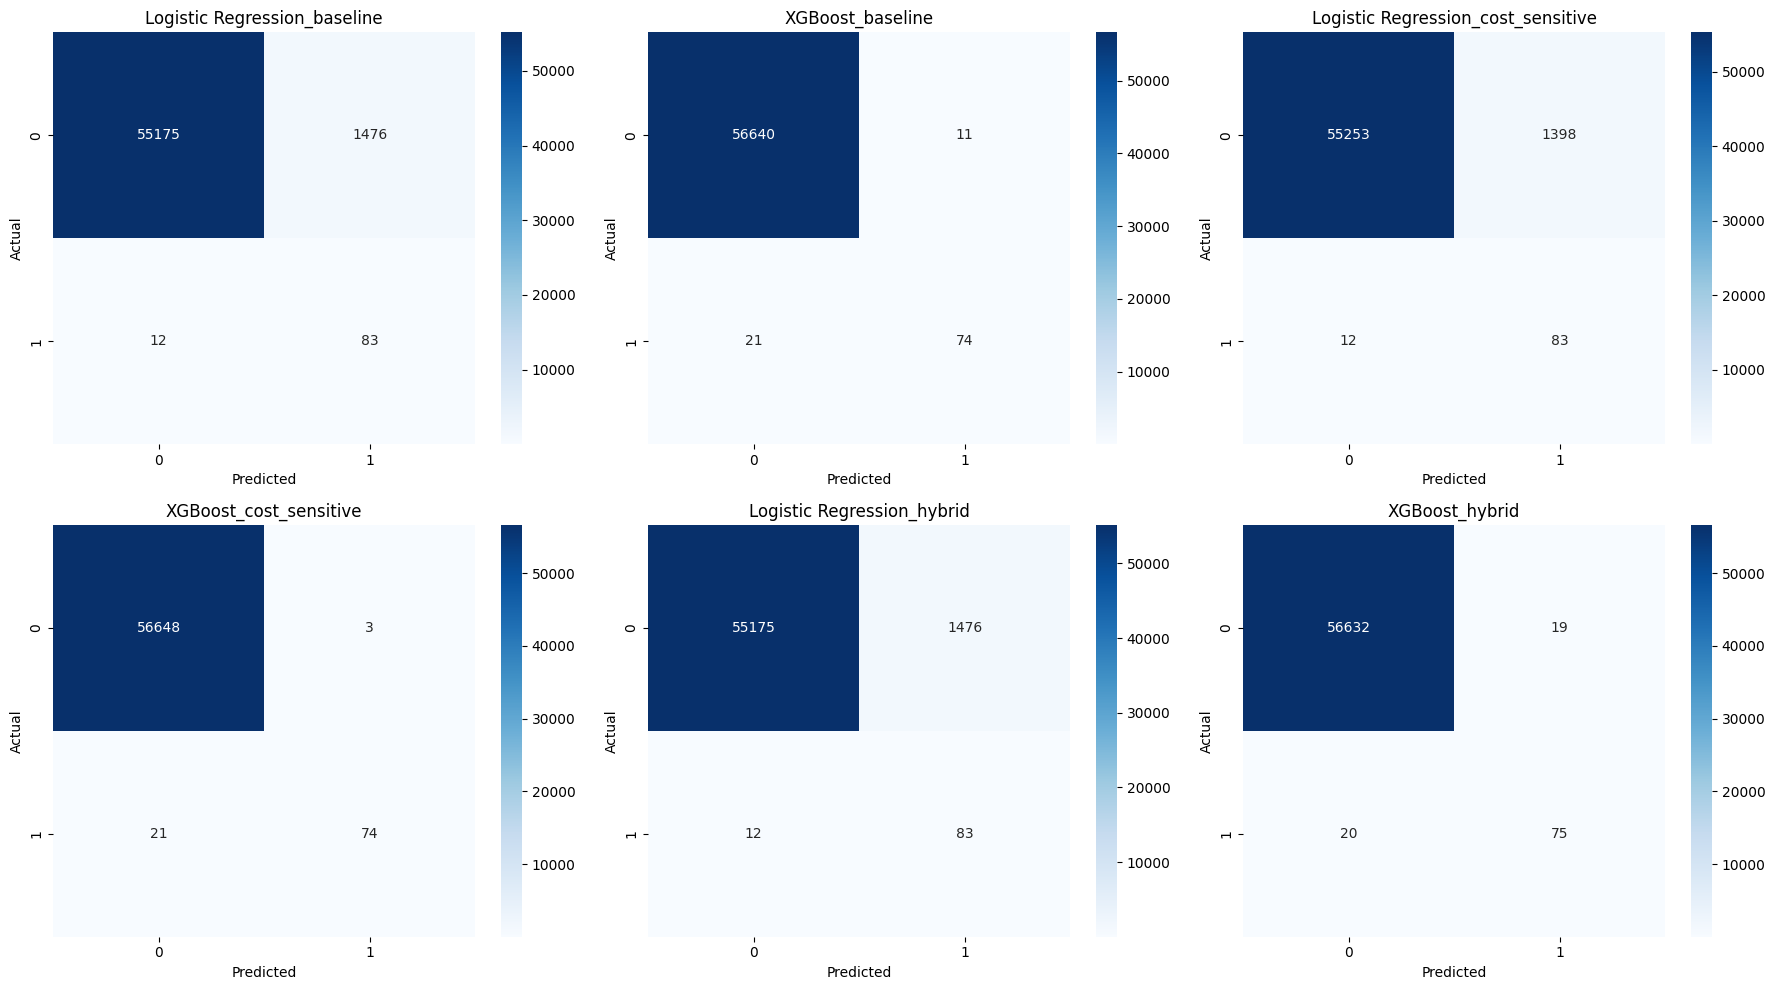

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (name, model) in zip(
        axes.flat, models.items()):
    cm = confusion_matrix(
        y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)

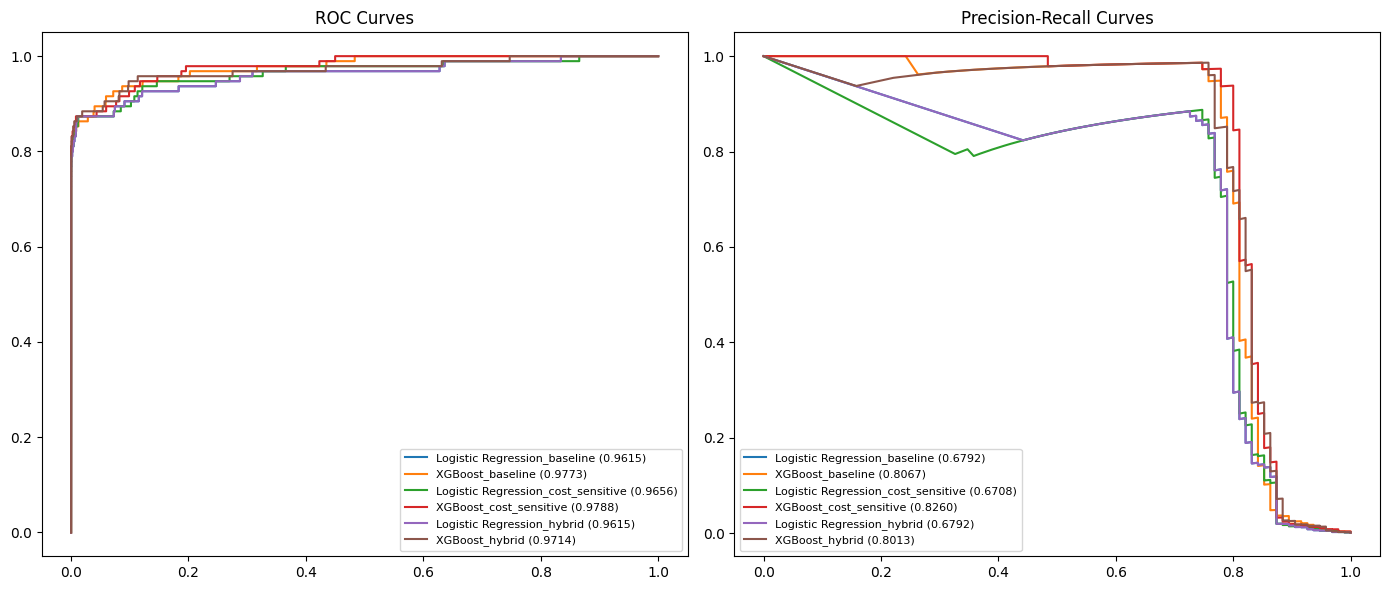

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr,
        label=f'{name} ({auc:.4f})')
    # PR curve
    prec, rec, _ = precision_recall_curve(
        y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec,
        label=f'{name} ({ap:.4f})')

axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=8)
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150)

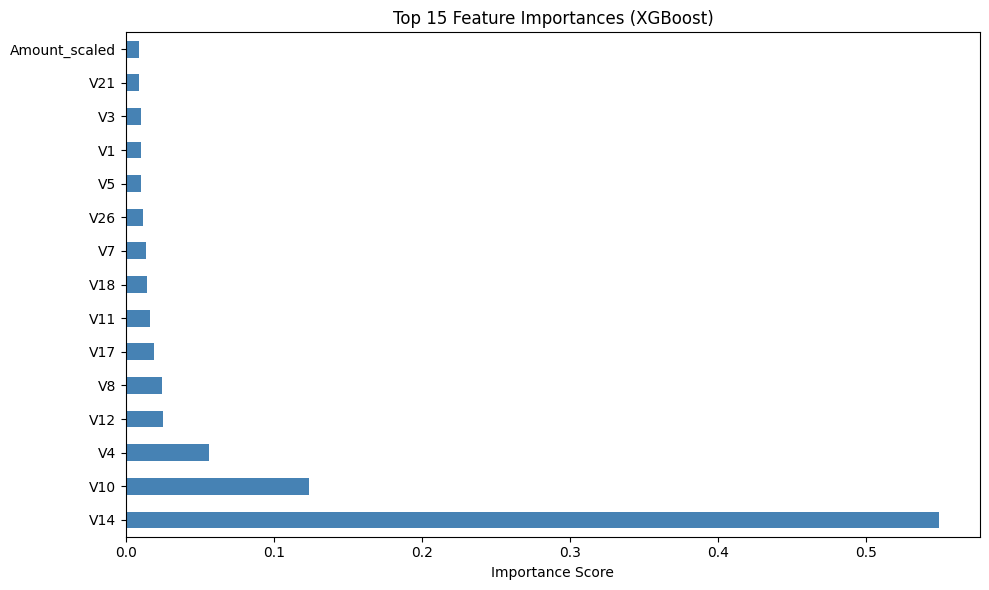

In [42]:
# XGBoost baseline feature importance
best_xgb = models['XGBoost_baseline']
clf = best_xgb.named_steps['classifier']
feat_imp = pd.Series(
    clf.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)